## 1. Introduction

In [1]:
import cartopy.crs as ccrs
import joblib
import pandas as pd
import seaborn as sns
import shap
import matplotlib.pyplot as plt
import numpy as np

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV, KFold

## 2. Data Processing

### 2.1. Data Import

In [2]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('./data/legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]

biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [3]:
df_countries = pd.read_csv('./data/gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
df_countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


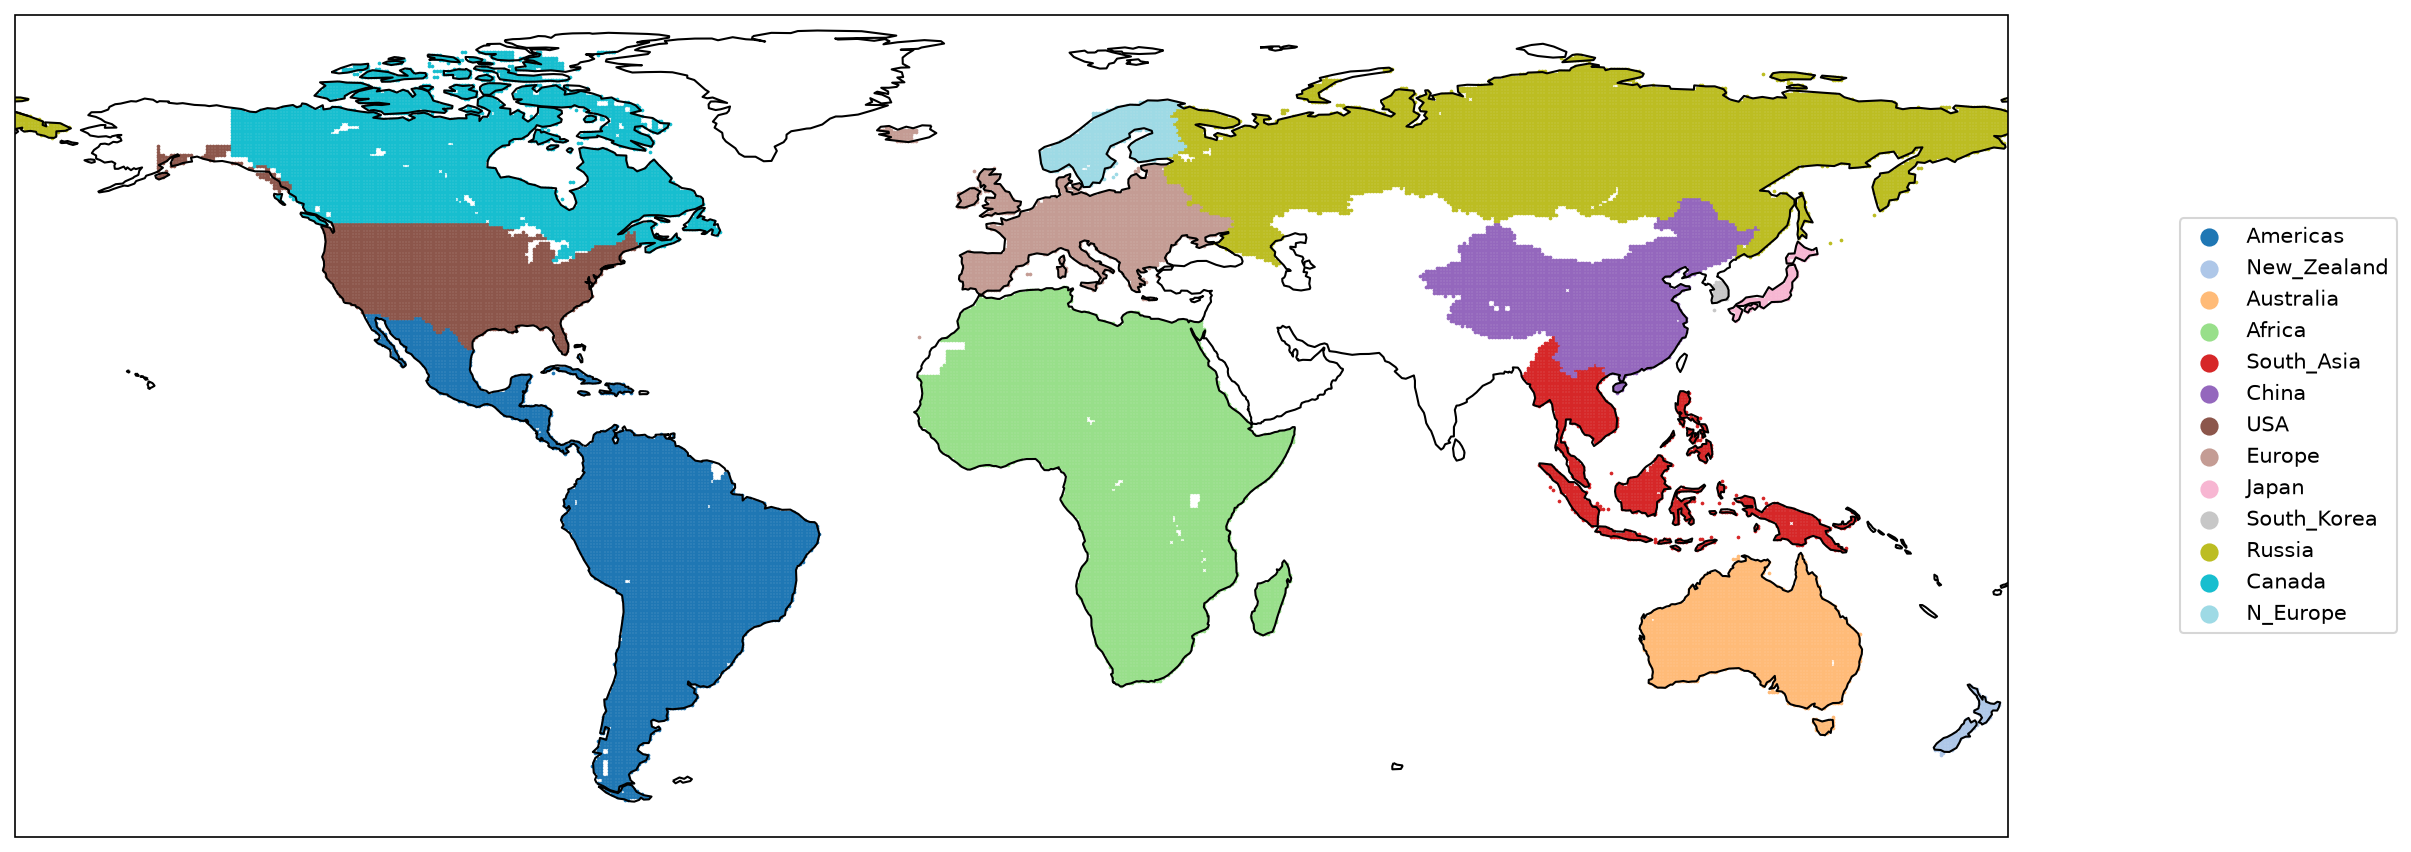

In [4]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

countries = df_countries["Pan_2007"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(countries)))

for i, name in enumerate(countries):
    country = df_countries[df_countries["Pan_2007"] == name]
    ax.scatter(country["Lon"], country["Lat"], color=colors[i], s=0.6, label=name, transform=proj)

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [5]:
region_mapping = {
    "Russia": "Russia",

    "Africa": "Africa",

    "Americas": "Latin_Americas",

    "Canada": "North_Americas",
    "USA": "North_Americas",

    "Australia": "Oceania",
    "New_Zealand": "Oceania",

    "Europe": "Europe",
    "N_Europe": "Europe",

    "South_Asia": "South_Asia",

    "Japan": "East_Asia",
    "South_Korea": "East_Asia",
    "China": "East_Asia"
}

df_countries["Region"] = (
    df_countries["Pan_2007"]
    .map(region_mapping)
)

df_countries["Region"].value_counts()

Region
Russia            11696
Africa            10164
North_Americas     9953
Latin_Americas     7176
East_Asia          3980
Europe             3229
Oceania            2961
South_Asia         1691
Name: count, dtype: int64

In [6]:
df_lpj = pd.read_csv('./data/LPJ-GUESS_output_BERN1.csv')
df_lpj.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [7]:
biome_data = df_lpj[["Lon", "Lat", "Biome_obs"]]
biome_data["Biome_obs"].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/xray/miniforge3/envs/bern01/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


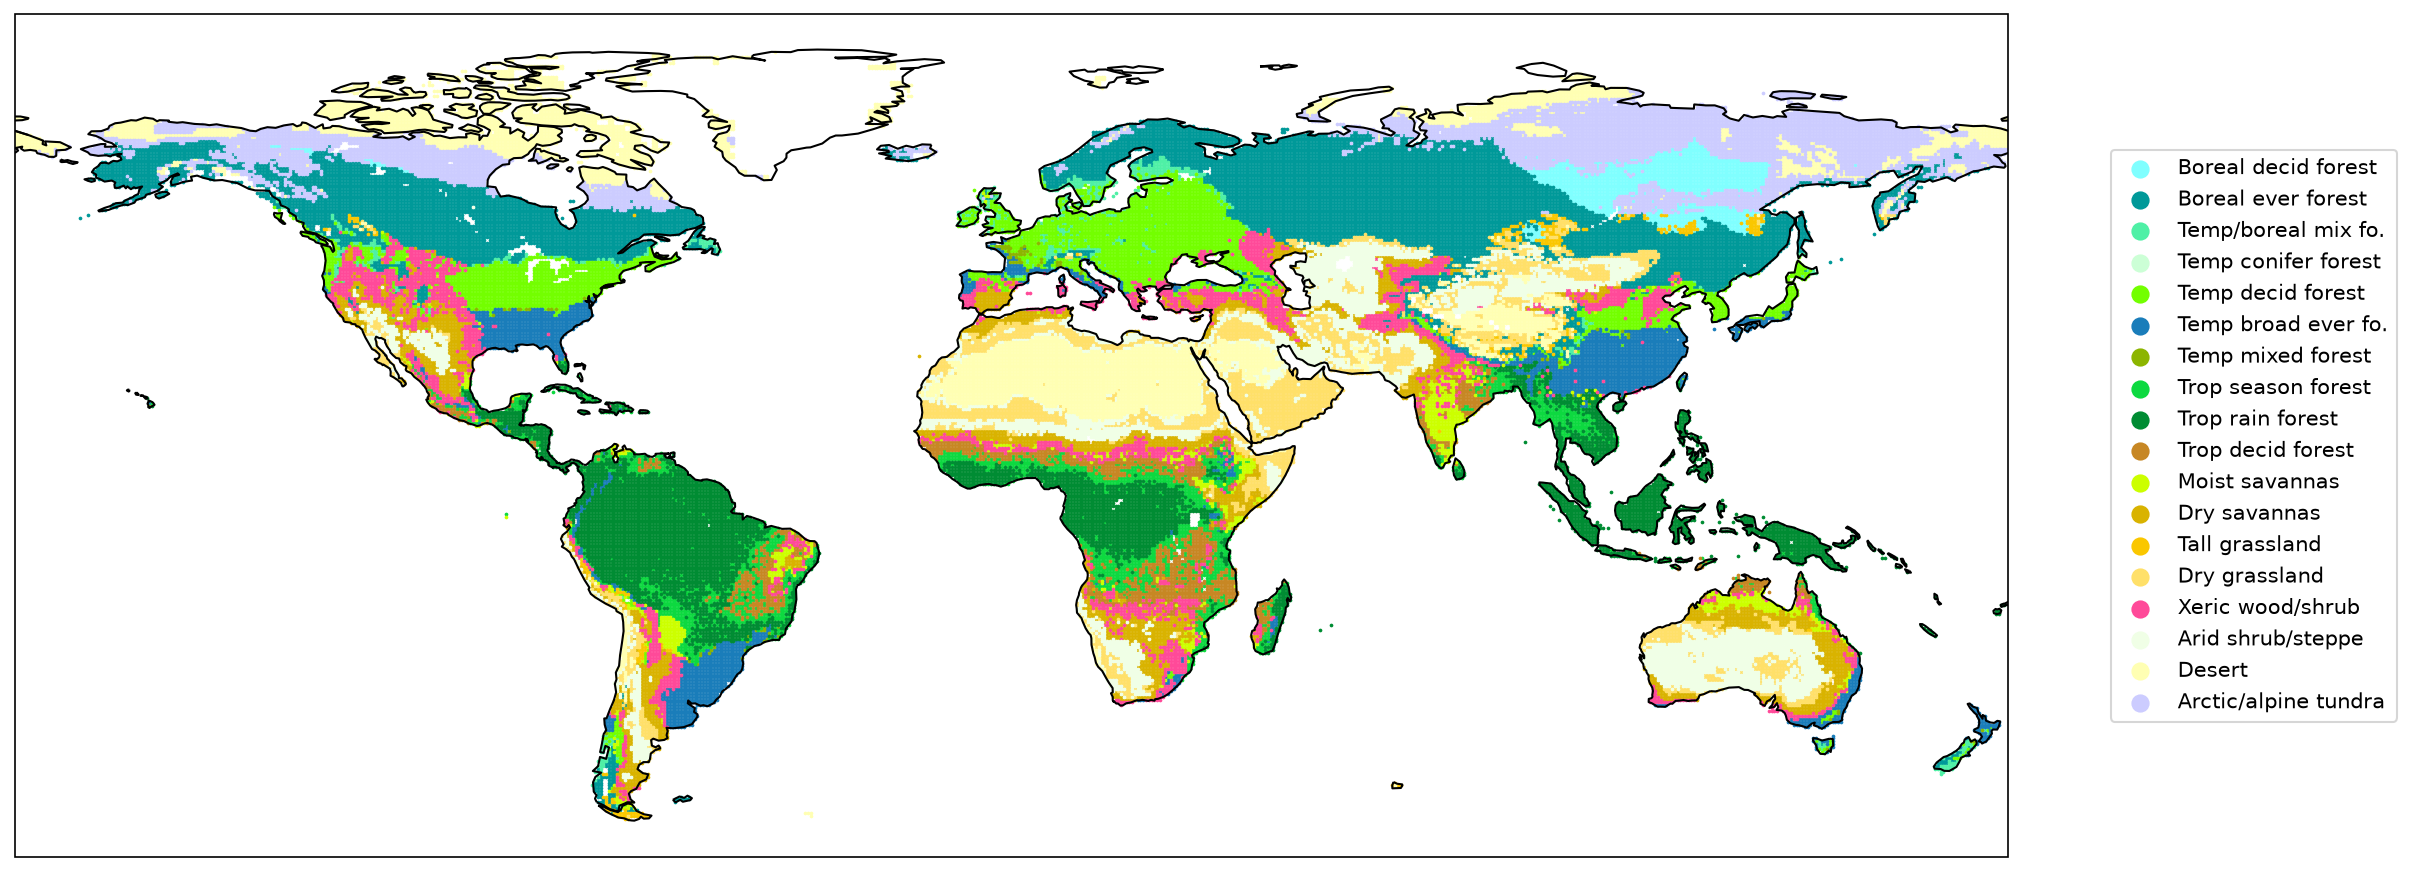

In [8]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i + 1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=0.6, label=name, marker='o')

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [9]:
file_dir = "./data/"
df_P = pd.read_csv(file_dir + "Predaymean1961_1990_stats.csv")
df_T_max = pd.read_csv(file_dir + "Tmaxdaymean1961_1990_stats.csv")
df_T_min = pd.read_csv(file_dir + "Tmindaymean1961_1990_stats.csv")
df_T_mean = pd.read_csv(file_dir + "Tmpdaymean1961_1990_stats.csv")
df_radiation = pd.read_csv(file_dir + "Tswrfdaymean1961_1990_stats.csv")
df_soil = pd.read_csv(file_dir + "soilmap.dat", sep=r"\s+")

In [10]:
df_soil.rename(columns={
    "lon": "Lon",
    "lat": "Lat",
}, inplace=True)

df_soil.head()

,Lon,Lat,clay,silt,sand,orgC,CN,pH,cellfraction
0,-179.75,71.25,0.08,0.37,0.55,0.020,11.0,5.9,0.482
1,-179.75,68.75,0.20,0.48,0.32,0.031,17.0,6.3,0.753
2,-179.75,68.25,0.20,0.48,0.32,0.031,17.0,6.3,0.447
3,-179.75,67.75,0.20,0.48,0.32,0.031,17.0,6.3,0.526
4,-179.75,67.25,0.20,0.48,0.32,0.031,17.0,6.3,0.422


### 2.2. Data Analysis

In [11]:
dfs = [
    df_lpj,
    df_P,
    df_T_max,
    df_T_min,
    df_T_min,
    df_radiation,
    df_soil,
    df_countries
]

for df in dfs:
    print(df.shape)

(59191, 12)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 9)
(50850, 8)


In [12]:
for df in dfs:
    print(df[["Lon", "Lat"]].duplicated().sum())

0
0
0
0
0
0
0
0


In [13]:
coords = (
    df_lpj[["Lon", "Lat"]]
    .sort_values(["Lon", "Lat"])
    .reset_index(drop=True)
)

for df in dfs[1:]:
    others = (
        df[["Lon", "Lat"]]
        .sort_values(["Lon", "Lat"])
        .reset_index(drop=True)
    )
    print(coords.equals(others))

True
True
True
True
True
True
False


### 2.3. Data Transformations

In [14]:
group_countries = df_countries[
    ["Lon", "Lat", "Region"]
]
feat_P = df_P[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "P_SpringMean", 
    "SummerMean": "P_SummerMean", 
    "FallMean": "P_FallMean", 
    "WinterMean": "P_WinterMean"
})
feat_T_max = df_T_max[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_max_SpringMean", 
    "SummerMean": "T_max_SummerMean", 
    "FallMean": "T_max_FallMean", 
    "WinterMean": "T_max_WinterMean"
})
feat_T_min = df_T_min[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_min_SpringMean", 
    "SummerMean": "T_min_SummerMean", 
    "FallMean": "T_min_FallMean", 
    "WinterMean": "T_min_WinterMean"
})
feat_T_mean = df_T_mean[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_mean_SpringMean", 
    "SummerMean": "T_mean_SummerMean", 
    "FallMean": "T_mean_FallMean", 
    "WinterMean": "T_mean_WinterMean"
})
feat_R_mean = df_radiation[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "R_mean_SpringMean", 
    "SummerMean": "R_mean_SummerMean", 
    "FallMean": "R_mean_FallMean", 
    "WinterMean": "R_mean_WinterMean"
})
feat_soil = df_soil[["Lon", "Lat", "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"]]
targe_lpj = df_lpj[["Lon", "Lat", "NPP", "VegC", "Biome_Cmax", "Biome_LAI", "Biome_obs"]]

In [15]:
df_data = (
    group_countries
    .merge(feat_P, on=["Lat", "Lon"])
    .merge(feat_T_max, on=["Lat", "Lon"])
    .merge(feat_T_min, on=["Lat", "Lon"])
    .merge(feat_T_mean, on=["Lat", "Lon"])
    .merge(feat_R_mean, on=["Lat", "Lon"])
    .merge(feat_soil, on=["Lat", "Lon"])
    .merge(targe_lpj, on=["Lat", "Lon"])
)
df_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.43,0.014,11.0,7.6,0.339,0.646,0.719,11,11,13
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.43,0.014,11.0,7.6,0.340,0.654,0.724,11,11,13
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.43,0.014,11.0,7.6,0.339,0.715,0.831,11,11,13
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.43,0.014,11.0,7.6,0.340,0.682,0.768,11,11,13
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.43,0.014,11.0,7.6,0.340,0.583,0.644,11,11,13


## 3. Data Description and Visualization

Features Correlation Heatmap (Global)

In [16]:
def draw_heatmap(df: pd.DataFrame):
    corr_matrix = df.corr()

    figure, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)

    ax.set_title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

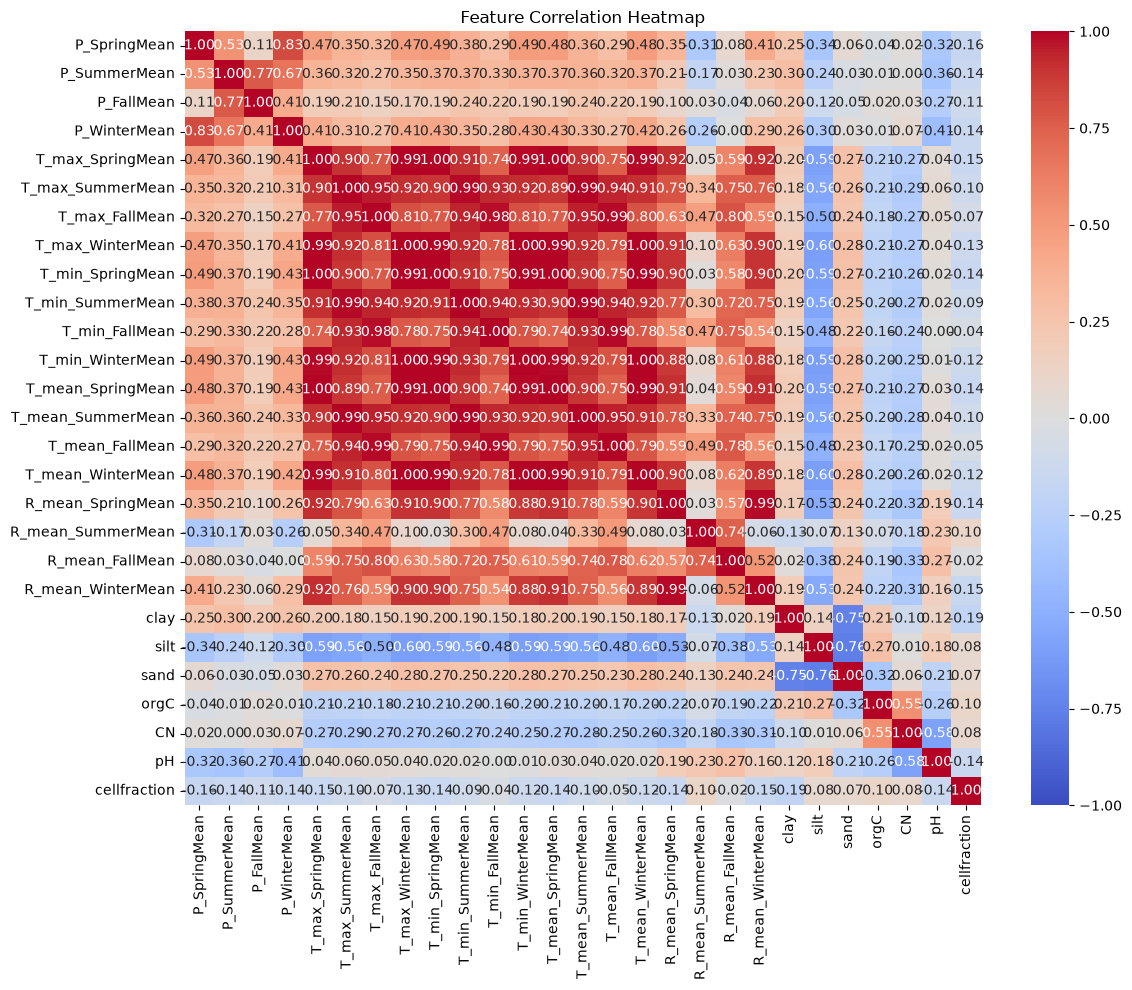

In [17]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_max_SpringMean", "T_max_SummerMean", "T_max_FallMean", "T_max_WinterMean", 
    "T_min_SpringMean", "T_min_SummerMean", "T_min_FallMean", "T_min_WinterMean",
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "R_mean_SpringMean", "R_mean_SummerMean", "R_mean_FallMean", "R_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

draw_heatmap(df_data[feature_cols])

Histogram

In [ ]:
# TODO

## 4. Biome Classification

### 4.1. Binary Classification

Biome Selected: 9 Trop rain forest

Latin_Americas -> Africa

#### 4.1.1. Data Split

##### 4.1.1.1 Data Processing

In [ ]:
df_bin = df_data.copy()
df_bin["Biome_rainforest"] = np.where(df_bin["Biome_obs"] == 9, 0, 1)
df_bin.head()

In [ ]:
pd.crosstab(
    df_bin["Region"],
    df_bin["Biome_rainforest"],
    normalize="index"
)

In [ ]:
test_data = df_bin[df_bin["Region"] == "Africa"].copy()
training_data = df_bin[df_bin["Region"] == "Latin_Americas"].copy()
test_data.head()

In [ ]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "R_mean_SpringMean", "R_mean_SummerMean", "R_mean_FallMean", "R_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = training_data[feature_cols]
y = training_data["Biome_rainforest"]

X_test = test_data[feature_cols]
y_test = test_data["Biome_rainforest"]

##### 4.1.1.2. Data Analysis

In [ ]:
X.describe()

In [ ]:
X_test.describe()

In [ ]:
draw_heatmap(X)

#### 4.1.2. Model Training

In [ ]:
rfc_bin = RandomForestClassifier(random_state=7)
rfc_bin.fit(X, y)

#### 4.1.3. Model Evaluation

In [ ]:
best_model_bin = rfc_bin

In [ ]:
y_test_pred = best_model_bin.predict(X_test)

print(
    metrics.classification_report(
        y_test,
        y_test_pred,
        target_names=["rainforest", "non_rainforest"]
    )
)

In [ ]:
metrics.ConfusionMatrixDisplay.from_estimator(
    best_model_bin, X_test, y_test, display_labels=['High', 'Low'], 
)
plt.show()

#### 4.1.4. Feature Importance

In [ ]:
importance = pd.Series(
    best_model_bin.feature_importances_,
    index=feature_cols
)

print(importance.sort_values(ascending=False))

In [ ]:
colors = plt.cm.viridis_r(np.linspace(0, 1, len(importance)))
importance.sort_values().plot.barh(
    figsize=(8, 6),
    xlabel="Feature Importance",
    color=colors
)
plt.show()

### 4.2. Multiclass Classification

North_Americas -> Europe

#### 4.2.1. Data Split

##### 4.2.1.1. Data Processing

In [ ]:
df_multi = df_data.copy()
df_multi.head()

In [ ]:
pd.crosstab(df_multi["Region"], df_multi["Biome_obs"])

In [ ]:
df_multi_subset = df_multi[df_multi["Region"].isin(["Europe", "North_Americas"])]
pd.crosstab(df_multi_subset["Region"], df_multi_subset["Biome_obs"])

In [ ]:
training_data = df_multi[df_multi["Region"] == "North_Americas"].copy()
test_data = df_multi[df_multi["Region"] == "Europe"].copy()
test_data.head()

In [ ]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "R_mean_SpringMean", "R_mean_SummerMean", "R_mean_FallMean", "R_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = training_data[feature_cols]
y = training_data["Biome_obs"]

X_test = test_data[feature_cols]
y_test = test_data["Biome_obs"]

##### 4.2.1.2. Data Analysis

In [ ]:
X.describe()

In [ ]:
X_test.describe()

In [ ]:
draw_heatmap(X)

#### 4.2.2. Model Fitting

In [ ]:
rfc_multi = RandomForestClassifier(random_state=7)
rfc_multi.fit(X, y)

#### 4.2.3. Hyperparameter Tuning

In [ ]:
TUNE_HYPER_PARAM = False

In [ ]:
if TUNE_HYPER_PARAM:
    folds = KFold(5, random_state=7, shuffle=True)

    param_grid = {
        "n_estimators": [180, 200, 220, 240],
        "max_depth": [18, 20, 22, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None]
    }

    rfc_gscv = GridSearchCV(
        rfc_multi,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=folds,
        n_jobs=-1
    )
    rfc_gscv.fit(X, y)

In [ ]:
if TUNE_HYPER_PARAM:
    joblib.dump(rfc_gscv.best_estimator_, "./output/best_rf_multi.pkl")

#### 4.2.4. Model Evaluation

In [ ]:
# best_model_multi = rfc_multi
best_model_multi = joblib.load("./output/best_rf_multi.pkl")
best_model_multi

In [ ]:
y_test_pred = best_model_multi.predict(X_test)

print(
    metrics.classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax
)

ax.set_title("Normalized Confusion Matrix")
plt.show()

#### 4.2.5. Feature Importance

In [ ]:
importance = pd.Series(
    best_model_multi.feature_importances_,
    index=feature_cols
)

print(importance.sort_values(ascending=False))

In [ ]:
colors = plt.cm.viridis_r(np.linspace(0, 1, len(importance)))
importance.sort_values().plot.barh(
    figsize=(8, 6),
    xlabel="Feature Importance",
    color=colors
)
plt.show()

#### 4.2.6. LPJ-GUESS Comparison

In [ ]:
y_pred_Cmax = test_data["Biome_Cmax"]

print(
    metrics.classification_report(
        y_test,
        y_pred_Cmax,
        zero_division=0
    )
)

In [ ]:
y_pred_LAI = test_data["Biome_LAI"]

print(
    metrics.classification_report(
        y_test,
        y_pred_LAI,
        zero_division=0
    )
)

## 5. Regression

North_Americas -> Europe

### 5.1. NPP Regression

#### 5.1.1. Data Split

In [83]:
df_NPP = df_data.copy()
df_NPP.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.43,0.014,11.0,7.6,0.339,0.646,0.719,11,11,13
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.43,0.014,11.0,7.6,0.340,0.654,0.724,11,11,13
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.43,0.014,11.0,7.6,0.339,0.715,0.831,11,11,13
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.43,0.014,11.0,7.6,0.340,0.682,0.768,11,11,13
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.43,0.014,11.0,7.6,0.340,0.583,0.644,11,11,13


In [84]:
training_data = df_NPP[df_NPP["Region"] == "North_Americas"]
test_data = df_NPP[df_NPP["Region"] == "Europe"]
test_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
21369,-16.75,28.25,Europe,2.1857,0.64417,0.26000,2.3497,290.31,292.65,296.98,...,0.49,0.008,10.0,6.4,0.358,0.242,1.276,7,11,12
24447,23.75,35.25,Europe,4.0172,0.71599,0.29796,3.2339,286.98,294.62,299.84,...,0.43,0.014,11.0,7.6,0.500,0.200,1.562,7,7,15
24448,24.25,35.25,Europe,4.4053,0.82076,0.33170,3.4378,286.76,294.39,299.40,...,0.43,0.014,11.0,7.6,0.500,0.227,1.723,7,7,15
24449,24.75,35.25,Europe,4.3081,0.78534,0.31614,3.5223,286.43,294.05,298.83,...,0.49,0.008,10.0,6.4,0.512,0.240,1.783,7,7,15
24450,25.25,35.25,Europe,4.0288,0.75494,0.29717,3.3901,286.14,294.10,298.88,...,0.49,0.008,10.0,6.4,0.490,0.225,1.714,7,7,15


#### 5.1.2. Model Fitting

In [85]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "R_mean_SpringMean", "R_mean_SummerMean", "R_mean_FallMean", "R_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = training_data[feature_cols]
y = training_data["NPP"]

In [86]:
rfr_NPP = RandomForestRegressor(random_state=7)
rfr_NPP.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

#### 5.1.3. Model Evaluation

In [87]:
best_model_NPP = rfr_NPP

In [88]:
X_test = test_data[feature_cols]
y_test = test_data["NPP"]

y_test_pred = best_model_NPP.predict(X_test)
y_train_pred = best_model_NPP.predict(X)

In [89]:
rmse = metrics.root_mean_squared_error(y, y_train_pred)
r2 = metrics.r2_score(y, y_train_pred)

print("Training Data:")
print(f"RMSE = {rmse:.4f}")
print(f"R2 = {r2:.4f}")

Training Data:
RMSE = 0.0115
R2 = 0.9973


In [90]:
rmse = metrics.root_mean_squared_error(y_test, y_test_pred)
r2 = metrics.r2_score(y_test, y_test_pred)

print("Test Data:")
print(f"RMSE = {rmse:.4f}")
print(f"R2 = {r2:.4f}")

Test Data:
RMSE = 0.0826
R2 = 0.5279


In [91]:
rng = np.random.default_rng(7)
idx = rng.choice(len(X_test), size=300, replace=False)

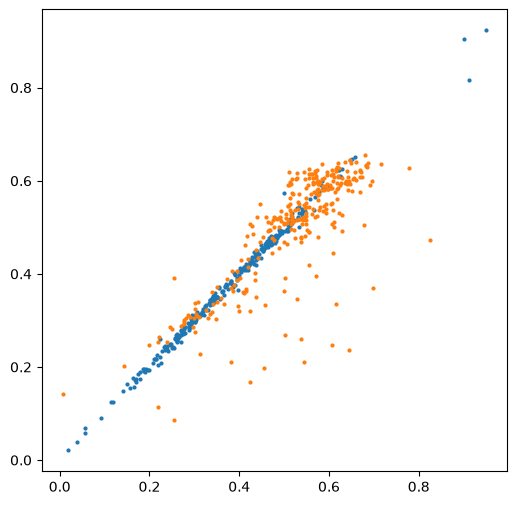

In [92]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y.iloc[idx], y_train_pred[idx], s=4)
ax.scatter(y_test.iloc[idx], y_test_pred[idx], s=4)
plt.show()

#### 5.1.4. Feature Importance

In [93]:
importance = pd.Series(
    best_model_NPP.feature_importances_,
    index=feature_cols
)

print(importance.sort_values(ascending=False))

T_mean_SummerMean    0.464499
T_mean_FallMean      0.289113
pH                   0.080137
R_mean_FallMean      0.066952
P_SummerMean         0.021082
P_FallMean           0.017684
R_mean_WinterMean    0.011714
R_mean_SpringMean    0.010544
T_mean_SpringMean    0.008611
R_mean_SummerMean    0.006908
T_mean_WinterMean    0.006801
P_SpringMean         0.006689
P_WinterMean         0.004306
cellfraction         0.001579
orgC                 0.001119
clay                 0.000793
silt                 0.000708
sand                 0.000636
CN                   0.000127
dtype: float64


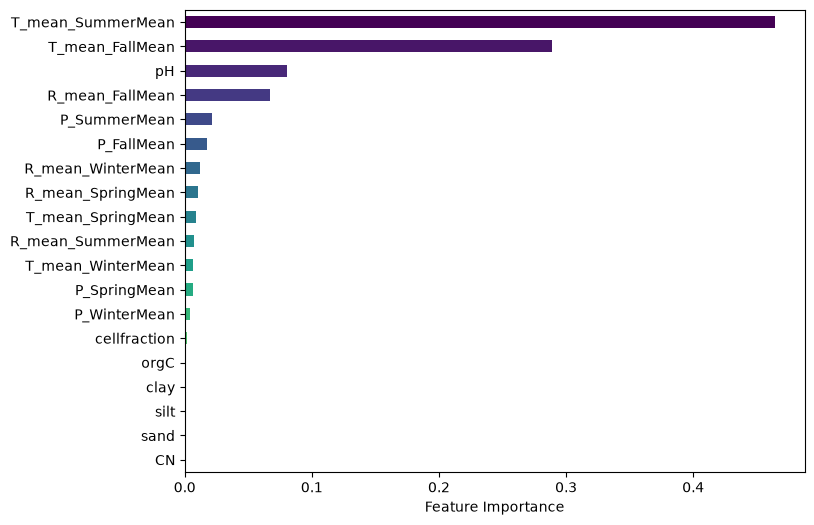

In [94]:
colors = plt.cm.viridis_r(np.linspace(0, 1, len(importance)))
importance.sort_values().plot.barh(
    figsize=(8, 6),
    xlabel="Feature Importance",
    color=colors
)
plt.show()

In [95]:
X_test_sample = X_test.iloc[idx]

explainer = shap.TreeExplainer(best_model_NPP)
shap_values = explainer(X_test_sample)

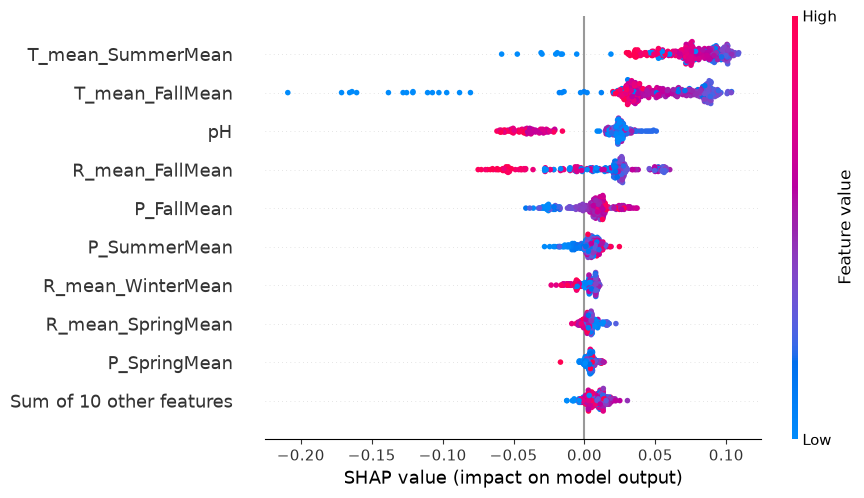

In [96]:
shap.plots.beeswarm(shap_values)

#### 5.1.5. LPJ-GUESS Comparison

In [97]:
# TODO

### 5.2. VegC Regression

#### 5.2.1. Data Split

In [98]:
df_VegC = df_data.copy()
df_VegC.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.43,0.014,11.0,7.6,0.339,0.646,0.719,11,11,13
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.43,0.014,11.0,7.6,0.340,0.654,0.724,11,11,13
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.43,0.014,11.0,7.6,0.339,0.715,0.831,11,11,13
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.43,0.014,11.0,7.6,0.340,0.682,0.768,11,11,13
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.43,0.014,11.0,7.6,0.340,0.583,0.644,11,11,13


In [99]:
training_data = df_VegC[df_VegC["Region"] == "North_Americas"]
test_data = df_VegC[df_VegC["Region"] == "Europe"]
test_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_Cmax,Biome_LAI,Biome_obs
21369,-16.75,28.25,Europe,2.1857,0.64417,0.26000,2.3497,290.31,292.65,296.98,...,0.49,0.008,10.0,6.4,0.358,0.242,1.276,7,11,12
24447,23.75,35.25,Europe,4.0172,0.71599,0.29796,3.2339,286.98,294.62,299.84,...,0.43,0.014,11.0,7.6,0.500,0.200,1.562,7,7,15
24448,24.25,35.25,Europe,4.4053,0.82076,0.33170,3.4378,286.76,294.39,299.40,...,0.43,0.014,11.0,7.6,0.500,0.227,1.723,7,7,15
24449,24.75,35.25,Europe,4.3081,0.78534,0.31614,3.5223,286.43,294.05,298.83,...,0.49,0.008,10.0,6.4,0.512,0.240,1.783,7,7,15
24450,25.25,35.25,Europe,4.0288,0.75494,0.29717,3.3901,286.14,294.10,298.88,...,0.49,0.008,10.0,6.4,0.490,0.225,1.714,7,7,15


#### 5.2.2. Model Fitting

In [100]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "R_mean_SpringMean", "R_mean_SummerMean", "R_mean_FallMean", "R_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = training_data[feature_cols]
y = training_data["VegC"]

In [101]:
rfr_VegC = RandomForestRegressor(random_state=7)
rfr_VegC.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

#### 5.2.3. Model Evaluation

In [102]:
best_model_VegC = rfr_VegC

In [103]:
X_test = test_data[feature_cols]
y_test = test_data["VegC"]

y_test_pred = best_model_VegC.predict(X_test)
y_train_pred = best_model_VegC.predict(X)

In [104]:
rmse = metrics.root_mean_squared_error(y, y_train_pred)
r2 = metrics.r2_score(y, y_train_pred)

print("Training Data:")
print(f"RMSE = {rmse:.4f}")
print(f"R2 = {r2:.4f}")

Training Data:
RMSE = 0.3136
R2 = 0.9890


In [105]:
rmse = metrics.root_mean_squared_error(y_test, y_test_pred)
r2 = metrics.r2_score(y_test, y_test_pred)

print("Test Data:")
print(f"RMSE = {rmse:.4f}")
print(f"R2 = {r2:.4f}")

Test Data:
RMSE = 1.9880
R2 = 0.4349


In [106]:
rng = np.random.default_rng(7)
idx = rng.choice(len(X_test), size=300, replace=False)

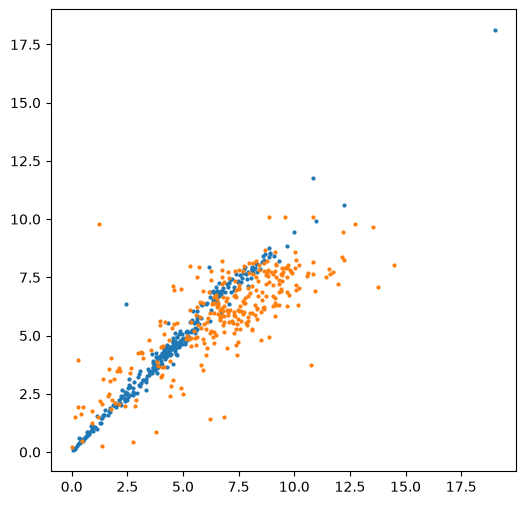

In [107]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y.iloc[idx], y_train_pred[idx], s=4)
ax.scatter(y_test.iloc[idx], y_test_pred[idx], s=4)
plt.show()

#### 5.2.4. Feature Importance

In [62]:
importance = pd.Series(
    best_model_VegC.feature_importances_,
    index=feature_cols
)

print(importance.sort_values(ascending=False))

T_mean_SummerMean    0.533552
P_FallMean           0.166771
R_mean_WinterMean    0.073854
T_mean_FallMean      0.055548
P_SummerMean         0.038896
T_mean_WinterMean    0.023701
T_mean_SpringMean    0.022284
P_WinterMean         0.021814
R_mean_FallMean      0.016801
R_mean_SummerMean    0.012724
R_mean_SpringMean    0.010598
P_SpringMean         0.008055
cellfraction         0.006117
pH                   0.003891
clay                 0.001598
orgC                 0.001425
silt                 0.001083
sand                 0.000931
CN                   0.000358
dtype: float64


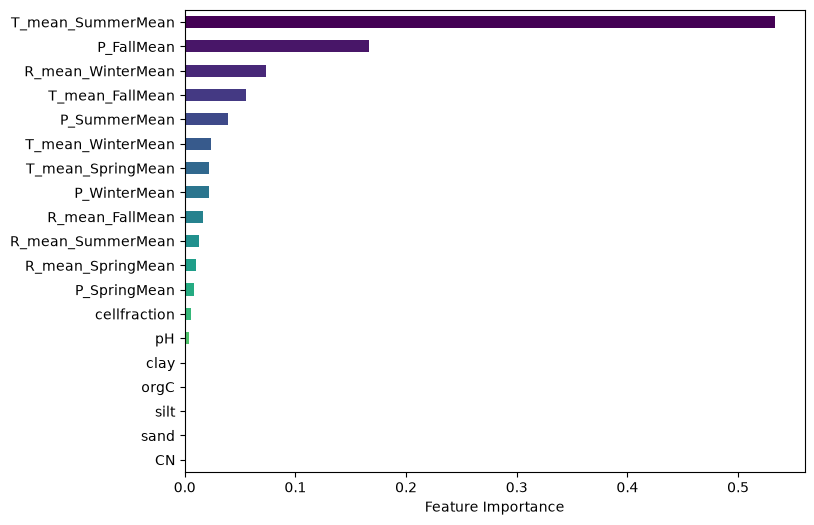

In [63]:
colors = plt.cm.viridis_r(np.linspace(0, 1, len(importance)))
importance.sort_values().plot.barh(
    figsize=(8, 6),
    xlabel="Feature Importance",
    color=colors
)
plt.show()

In [66]:
X_test_sample = X_test.iloc[idx]

explainer = shap.TreeExplainer(best_model_VegC)
shap_values = explainer(X_test_sample)

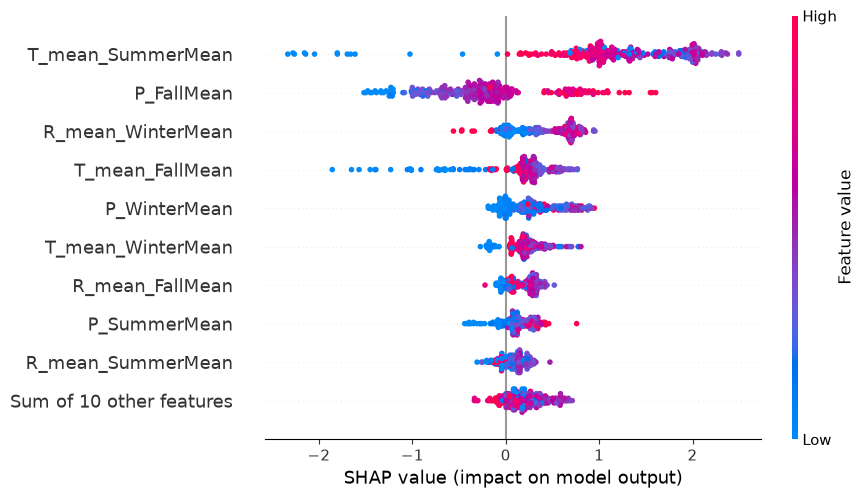

In [67]:
shap.plots.beeswarm(shap_values)

#### 5.2.5. LPJ-GUESS Performance

In [ ]:
# TODO
fig, ax = plt.subpolts()
